In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

![alt text](image-1.png)

![alt text](image.png)
H(X) là entropy của X (0 <= H(X) <= log2m)
- Xem xét m = 2, trong trường hợp X là tinh khiết nhất, tức là một trong hai pi bằng 0 và giá trị kia bằng 1, khi đó H(X) = 0. Khi X là vẩn đục nhất tức cả hai xác suất mang giá trị pi = 0.5, hàm entropy đạt giá trị cao nhất.
- Vậy với m > 2,hàm entropy đạt giá trị nhỏ nhất nếu có một giá trị pi = 1 (tức các giá trị pi còn lại mang giá trị 0), đạt giá trị lớn nhất nếu tất cả pi bằng nhau.
Giá trị entropy:
Lớn: Phân phối P(X) gần với dạng phân phối đồng nhất (uniform distribution)
Nhỏ: Phân phối P(X) xa dạng phân phối đồng nhất
Entropy điều kiện H(Y|X)
H(Y|X) = trung bình các giá trọ entropy điều kiện cụ thể H(Y|X = v) 
Information Gain IG(Y|X)
IG(Y|X) là số lượng bit trung bình có thể tiết kiệm khi truyền Y mà hai đầu gửi và nhận đã biết X.
Tức là: IG(Y|X) = H(Y) - H(Y|X)
Ví dụ:
H(Y) = 1
H(Y|X) = 0.5
IG(Y|X) = 1 - 0.5 = 0.5
https://machinelearningcoban.com/2018/01/14/id3/

In [2]:
from sklearn import datasets
import warnings
warnings.filterwarnings('ignore')

In [17]:
iris = datasets.load_iris()

In [18]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [19]:
iris['data']

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [6]:
iris['feature_names']

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [7]:
iris['target'] 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
df =  pd.DataFrame(data=np.c_[iris['data'],iris['target']],columns=iris['feature_names']+['target'])

In [9]:
#np.c_ is used to concatenate two arrays along the second axis (columns).   

In [10]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2.0
146,6.3,2.5,5.0,1.9,2.0
147,6.5,3.0,5.2,2.0,2.0
148,6.2,3.4,5.4,2.3,2.0


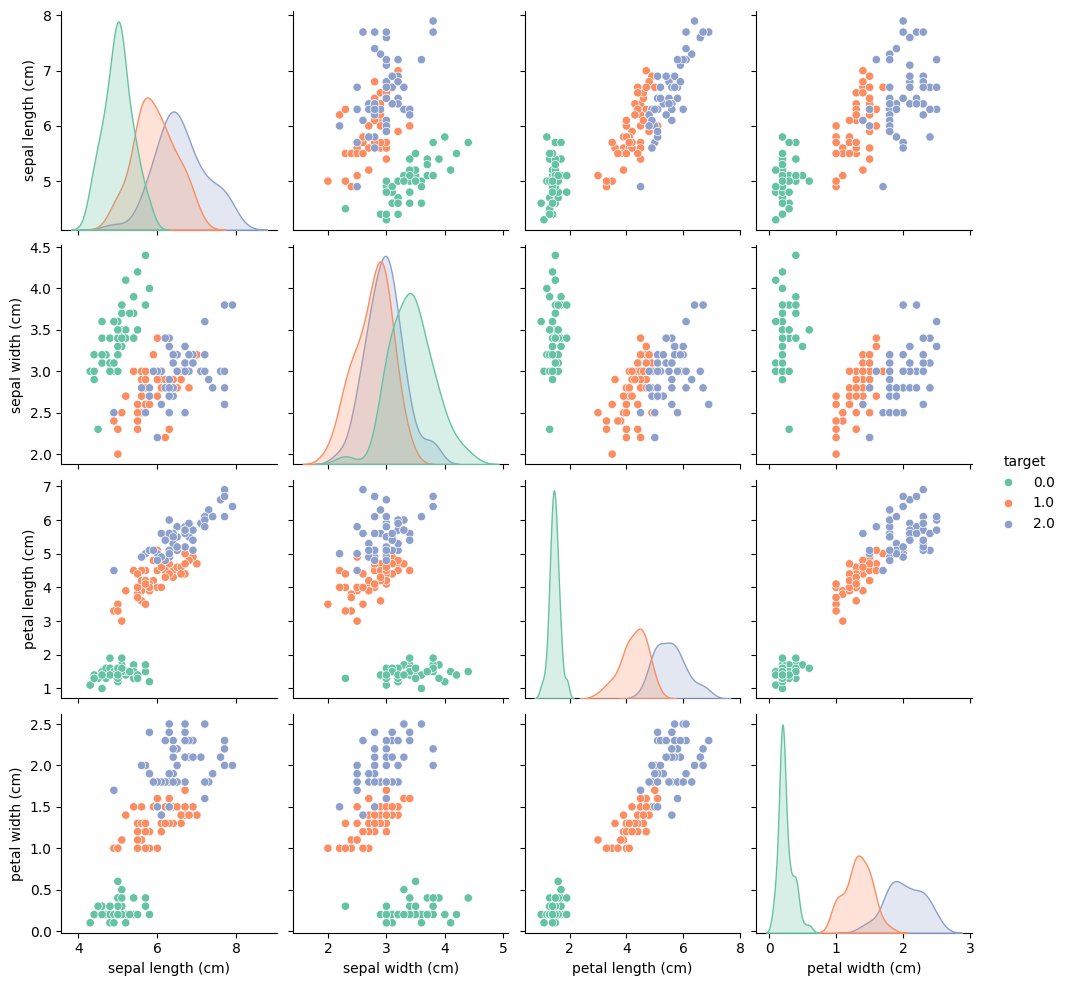

In [11]:
sns.pairplot(df,hue='target',palette='Set2') #palette is used to change the color of the plot
#types of palette: Set1, Set2, Set3, Paired, Dark2, Accent

In [12]:
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier



In [13]:
model = DecisionTreeClassifier()
model.fit(iris['data'],iris['target'])

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
model.score(iris['data'],iris['target'])

1.0

2.Xem kích thước & tính chất dữ liệu

Số mẫu nhiều, số đặc trưng (feature) ít → các mô hình phức tạp (Random Forest, Gradient Boosting, Neural Network) có thể phát huy.

Số mẫu ít, đặc trưng nhiều → nên chọn mô hình đơn giản hoặc có regularization mạnh (Logistic Regression, Linear Regression, SVM).
3. Độ phức tạp quan hệ giữa đầu vào và đầu ra

Quan hệ tuyến tính, gần thẳng → Linear Regression / Logistic Regression.

Quan hệ phi tuyến, phức tạp → Random Forest, Gradient Boosting, Neural Network.

4. Nhu cầu về khả năng giải thích (interpretability)

Nếu bạn cần giải thích rõ ràng (tại sao mô hình ra quyết định): Linear/Logistic Regression, Decision Tree.

Nếu bạn cần độ chính xác cao, không quan trọng giải thích: Random Forest, Gradient Boosting (XGBoost, LightGBM, CatBoost), Neural Network.

5. Chiến lược chọn mô hình thực tế

Bắt đầu đơn giản trước: Linear/Logistic Regression, Decision Tree.

Nếu kết quả chưa đủ tốt → thử Random Forest, SVM.

Nếu dữ liệu lớn và phức tạp → Gradient Boosting (XGBoost, LightGBM) hoặc Neural Network.

In [15]:
expected = iris['target']
predicted = model.predict(iris['data'])
print(metrics.classification_report(expected, predicted))
print(metrics.confusion_matrix(expected, predicted))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50
           2       1.00      1.00      1.00        50

    accuracy                           1.00       150
   macro avg       1.00      1.00      1.00       150
weighted avg       1.00      1.00      1.00       150

[[50  0  0]
 [ 0 50  0]
 [ 0  0 50]]


Mô hình đạt độ chính xác 100%

In [45]:
from ipywidgets import interact
        
        

In [58]:
iris.data[:,0:4]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
def Decision_Tree(Type,Depth):
        iris = datasets.load_iris()
        X = iris.data[:, :2]  # lấy hai đặc trưng đầu tiên
        Y = iris.target
        h = .02  # bước nhảy trong lưới h = 0.02 → sẽ có [0.0, 0.02, 0.04, …, 1.0] → lưới dày hơn nhiều, vẽ đường biên mịn hơn.
        # tạo một instance của Decision Tree Classifier và fit dữ liệu.
        model =DecisionTreeClassifier(criterion=Type,max_depth=Depth)  
        model.fit(X, Y)
        # Cho mỗi điểm trong lưới, dự đoán lớp của nó.
        # [x_min, m_max]x[y_min, y_max].
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h)) #np.meshgrid: tạo lưới tọa độ từ hai mảng 1D
         # Dự đoán lớp cho mỗi điểm trong lưới
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])#reval(): trả về một mảng 1D
        Z = Z.reshape(xx.shape)
        plt.figure(1, figsize=(4, 3))
        plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired) #pcolormesh: vẽ lưới màu
        # Plot also the training points
        plt.scatter(X[:, 0], X[:, 1], c=Y, edgecolors='k', cmap=plt.cm.Paired)
        plt.xlabel('Sepal length')
        plt.ylabel('Sepal width')
        plt.xlim(xx.min(), xx.max())
        plt.ylim(yy.min(), yy.max())
        plt.xticks(())
        plt.yticks(())
        plt.show()
interact(Decision_Tree,Type=['gini','entropy'],Depth=(1,10,1))

interactive(children=(Dropdown(description='Type', options=('gini', 'entropy'), value='gini'), IntSlider(value…

<function __main__.Decision_Tree(Type, Depth)>

In [67]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [59]:
df.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0


In [72]:
df[['target']].values

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],

In [78]:
def Decision_Tree2 (Type,Depth):
    x=df[['petal length (cm)','petal width (cm)']]
    y=df[['target']].values
    h = .02 
    Model =DecisionTreeClassifier(criterion = Type, max_depth = Depth)
    Model.fit(x,y)
    x_min, x_max = x.iloc[:, 0].min() - .5, x.iloc[:, 0].max() + .5 #tìm giá trị min, max của cột 0 (petal length)
    y_min, y_max = x.iloc[:, 1].min() - .5, x.iloc[:, 1].max() + .5
    xx,yy = np.meshgrid(np.arange(x_min,x_max,h),np.arange(y_min,y_max,h)) #tạo lưới tọa độ từ hai mảng 1D
    Z= Model.predict(np.c_[xx.ravel(),yy.ravel()]) #đưa lưới về dạng 1D để dự đoán
    Z=Z.reshape(xx.shape)
    plt.figure(figsize=(4,4))
     #cmap: bảng màu cho biểu đồ plt.cm.Paired: bảng màu gồm các cặp màu tương phản
    plt.pcolormesh(xx,yy,Z,cmap=plt.cm.Paired)# tạo mảng màu
    plt.scatter(x.iloc[:,0],x.iloc[:,1],c=y,edgecolors='b',cmap=plt.cm.Paired) #c=y: màu sắc 
    plt.xlabel('petal length (cm)')
    plt.ylabel('petal width (cm)')
    plt.xlim(xx.min(),xx.max())#plt.xlim: giới hạn trục x từ xx.min() đến xx.max()
    plt.ylim(yy.min(),yy.max())
    plt.xticks(())#xticks: vị trí của các vạch trên trục x plt.yticks: vị trí của các vạch trên trục y
    plt.yticks(())
    plt.show()
interact(Decision_Tree2,Type=['gini','entropy'],Depth=(1,10,1)) #interact: tạo giao diện tương tác giưa hàm và các widget
#widgets: Type (tiêu chí chia: gini, entropy), Depth (độ sâu tối đa của cây: từ 1 đến 10, bước nhảy 1)


interactive(children=(Dropdown(description='Type', options=('gini', 'entropy'), value='gini'), IntSlider(value…

<function __main__.Decision_Tree2(Type, Depth)>

Vì sao cần làm vậy?
Mục tiêu

Bạn có tập dữ liệu 2 chiều (2 feature), muốn nhìn trực quan xem mô hình phân loại (ở đây là Decision Tree) chia không gian thành những vùng nào.
Muốn vẽ vùng → bạn phải biết mô hình dự đoán nhãn ở mỗi điểm trong mặt phẳng.

Các bước

Tạo lưới điểm phủ toàn bộ không gian dữ liệu
→ dùng np.meshgrid để lấy tất cả tọa độ (x, y) trong hình chữ nhật bao quanh dữ liệu.

Biến ma trận lưới thành danh sách tọa độ
→ .ravel() và np.c_[] biến lưới 2D thành danh sách điểm để đưa vào model.predict().

Cho mô hình dự đoán nhãn cho tất cả các điểm
→ model.predict(...) cho bạn biết mỗi điểm thuộc lớp nào.

Chuyển kết quả về dạng 2D để vẽ bản đồ màu
→ reshape(xx.shape) đưa nhãn dự đoán về dạng ma trận có cùng kích thước lưới.
→ Sau đó dùng plt.contourf(xx, yy, Z, ...) để tô màu vùng theo lớp.
 Kết quả

Bạn sẽ có hình minh họa trực quan:

Các điểm dữ liệu thật (scatter plot).

Các vùng màu (decision boundary) cho thấy mô hình chia không gian ra sao.

Ví dụ khi kéo Depth trong cây quyết định:

Nếu Depth=1 → mô hình chỉ cắt 1 lần, đường biên thô.

Nếu Depth=10 → mô hình cắt nhiều lần, đường biên phức tạp hơn.

✅ Tóm gọn:
Mấy đoạn ravel(), np.c_[], reshape() chỉ là “xử lý kỹ thuật” để biến dữ liệu lưới thành dạng phù hợp → cho mô hình dự đoán → rồi biến ngược về dạng ma trận để vẽ bản đồ phân lớp.

DecisionTreeClassifier: lớp trong sklearn.tree dùng để tạo cây quyết định cho phân loại.

criterion=Type:

Đây là cách bạn chọn tiêu chuẩn (criterion) để đo “mức độ chia tách tốt” ở mỗi node của cây.

Thường có 2 lựa chọn:

"gini" → chỉ số Gini.

"entropy" → dựa trên entropy (thông tin thu được).

Trong code của bạn, Type có thể là biến chứa giá trị "gini" hoặc "entropy".

max_depth=Depth:

Đây là độ sâu tối đa của cây.

Nếu để None → cây sẽ phát triển cho đến khi các node lá thuần (pure).

Nếu để một số cụ thể (ví dụ 3, 5, 10) → cây sẽ dừng khi đạt độ sâu đó.

Trong code của bạn, Depth là một biến chứa số nguyên, ví dụ Depth = 4.